# mab x virus coverage explorer

Which mab/virus combinations exist, how many plates (`run_id`) each one shows up on, and which plates are the best candidates to demo "a few different mabs and viruses tested against each other" (i.e. a real cross-panel, not just one mab tested against a pile of viruses or vice versa).

**Assumptions -- check the printed message in the split cell below before trusting anything downstream:**
- Defaults to the 33-plate dataset (`33_plates_m4b_m5b_estimates_2026-09-13.csv`) since that's the one with the most plates/combos to choose from. Add other files to `DATA_PATHS` below (e.g. the six-plate `4PL_plate_fit_small_data` datasets) if you want a broader sweep.
- `mab_virus` looks like `22.0|103` in every category list I've seen from these models, so this assumes it's `<mab>|<virus>` and splits on `|`. If that assumption is wrong for some rows, the split cell falls back to treating `mab_virus` as one opaque label (still gives you combo counts and per-plate diversity, just not a proper mab x virus matrix).

Run under the `stan` WSL venv (`source ~/envs/stan/bin/activate`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("/mnt/c/Users/bhaddock/repos/titration_pnlme/single_mabs")

DATA_PATHS = [
    BASE / "input_data/retagged_data/33_plates_m4b_m5b_estimates_2026-09-13.csv",
    # add more files here to widen the search, e.g.:
    # BASE / "input_data/retagged_data/six_plates_with_estimates_specrole_2026-08-30.csv",
]

/home/bhaddock/envs/stan/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
# One row per (source file, run_id, mab_virus) -- dedupe out concentration/replicate rows,
# we only care about *presence*, not the titration data itself here.
frames = []
for path in DATA_PATHS:
    df = pd.read_csv(path, usecols=["run_id", "mab_virus"]).drop_duplicates()
    df["source_file"] = path.name
    frames.append(df)
combos = pd.concat(frames, ignore_index=True)
print(f"{len(combos)} unique (run_id, mab_virus) combos across {combos['run_id'].nunique()} plates "
      f"and {combos['mab_virus'].nunique()} distinct mab_virus labels, from {len(DATA_PATHS)} file(s).")
combos.head()

113 unique (run_id, mab_virus) combos across 33 plates and 80 distinct mab_virus labels, from 1 file(s).


,run_id,mab_virus,source_file
0,411,70.0|274,33_plates_m4b_m5b_estimates_2026-09-13.csv
1,411,69.0|274,33_plates_m4b_m5b_estimates_2026-09-13.csv
2,783,6.0|71,33_plates_m4b_m5b_estimates_2026-09-13.csv
3,783,69.0|71,33_plates_m4b_m5b_estimates_2026-09-13.csv
4,491,6.0|99,33_plates_m4b_m5b_estimates_2026-09-13.csv


In [3]:
# Try to split mab_virus into separate mab / virus ids. Falls back cleanly if the
# assumption doesn't hold for some rows -- everything below still works either way,
# just without a real 2D mab x virus matrix.
split = combos["mab_virus"].str.split("|", n=1, expand=True)
HAS_MAB_VIRUS_SPLIT = split.shape[1] == 2 and split[1].notna().all() and split[0].notna().all()

if HAS_MAB_VIRUS_SPLIT:
    combos["mab"] = split[0]
    combos["virus"] = split[1]
    print(f"Split cleanly: {combos['mab'].nunique()} distinct mabs x {combos['virus'].nunique()} distinct viruses.")
else:
    print("mab_virus did not split into exactly 2 non-null parts on '|' for every row -- "
          "treating it as one opaque label instead of separate mab/virus axes. "
          "Inspect `split` to see what happened.")

Split cleanly: 10 distinct mabs x 16 distinct viruses.


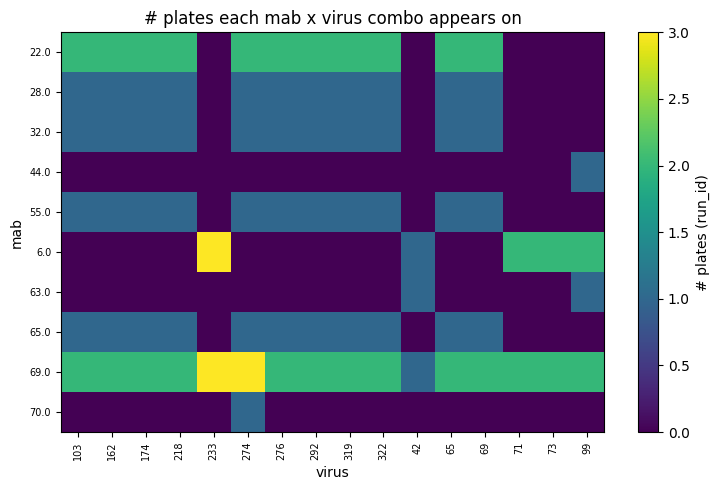

In [4]:
# Overall coverage: how many plates does each combo show up on?
if HAS_MAB_VIRUS_SPLIT:
    coverage = combos.groupby(["mab", "virus"])["run_id"].nunique().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(max(6, 0.35 * coverage.shape[1] + 2), max(5, 0.3 * coverage.shape[0] + 2)))
    im = ax.imshow(coverage.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(coverage.shape[1])); ax.set_xticklabels(coverage.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(coverage.shape[0])); ax.set_yticklabels(coverage.index, fontsize=7)
    ax.set_xlabel("virus"); ax.set_ylabel("mab")
    ax.set_title("# plates each mab x virus combo appears on")
    fig.colorbar(im, ax=ax, label="# plates (run_id)")
    fig.tight_layout()
else:
    plate_counts = combos.groupby("mab_virus")["run_id"].nunique().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, max(4, 0.2 * len(plate_counts))))
    ax.barh(plate_counts.index[::-1], plate_counts.values[::-1])
    ax.set_xlabel("# plates (run_id)")
    ax.set_title("# plates each mab_virus combo appears on")
    fig.tight_layout()

In [5]:
# Per-plate diversity. "cross_score" = min(#mabs, #viruses) on that plate -- a plate
# testing 8 mabs against 1 virus has 8 combos but a cross_score of 1 (not a cross-panel
# demo); a plate with 4 mabs x 4 viruses has a cross_score of 4 even with fewer raw combos.
agg = {"n_mab_virus": ("mab_virus", "nunique")}
if HAS_MAB_VIRUS_SPLIT:
    agg["n_mab"] = ("mab", "nunique")
    agg["n_virus"] = ("virus", "nunique")
plate_diversity = combos.groupby("run_id").agg(**agg)

if HAS_MAB_VIRUS_SPLIT:
    plate_diversity["cross_score"] = plate_diversity[["n_mab", "n_virus"]].min(axis=1)
    plate_diversity = plate_diversity.sort_values(["cross_score", "n_mab_virus"], ascending=False)
else:
    plate_diversity = plate_diversity.sort_values("n_mab_virus", ascending=False)

plate_diversity.head(15)

,n_mab_virus,n_mab,n_virus,cross_score
run_id,,,,
75,4,4,1,1
77,4,4,1,1
84,4,4,1,1
152,4,4,1,1
291,4,4,1,1
322,4,4,1,1
462,4,4,1,1
474,4,4,1,1
488,4,4,1,1


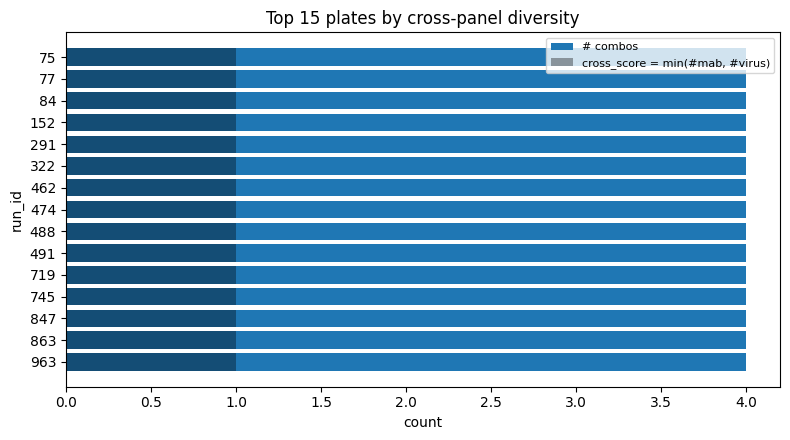

In [6]:
N_TOP = 15
top = plate_diversity.head(N_TOP)

fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(top))))
ax.barh(top.index.astype(str)[::-1], top["n_mab_virus"][::-1], label="# combos")
if HAS_MAB_VIRUS_SPLIT:
    ax.barh(top.index.astype(str)[::-1], top["cross_score"][::-1], color="black", alpha=0.35, label="cross_score = min(#mab, #virus)")
ax.set_xlabel("count")
ax.set_ylabel("run_id")
ax.set_title(f"Top {N_TOP} plates by cross-panel diversity")
ax.legend(fontsize=8)
fig.tight_layout()

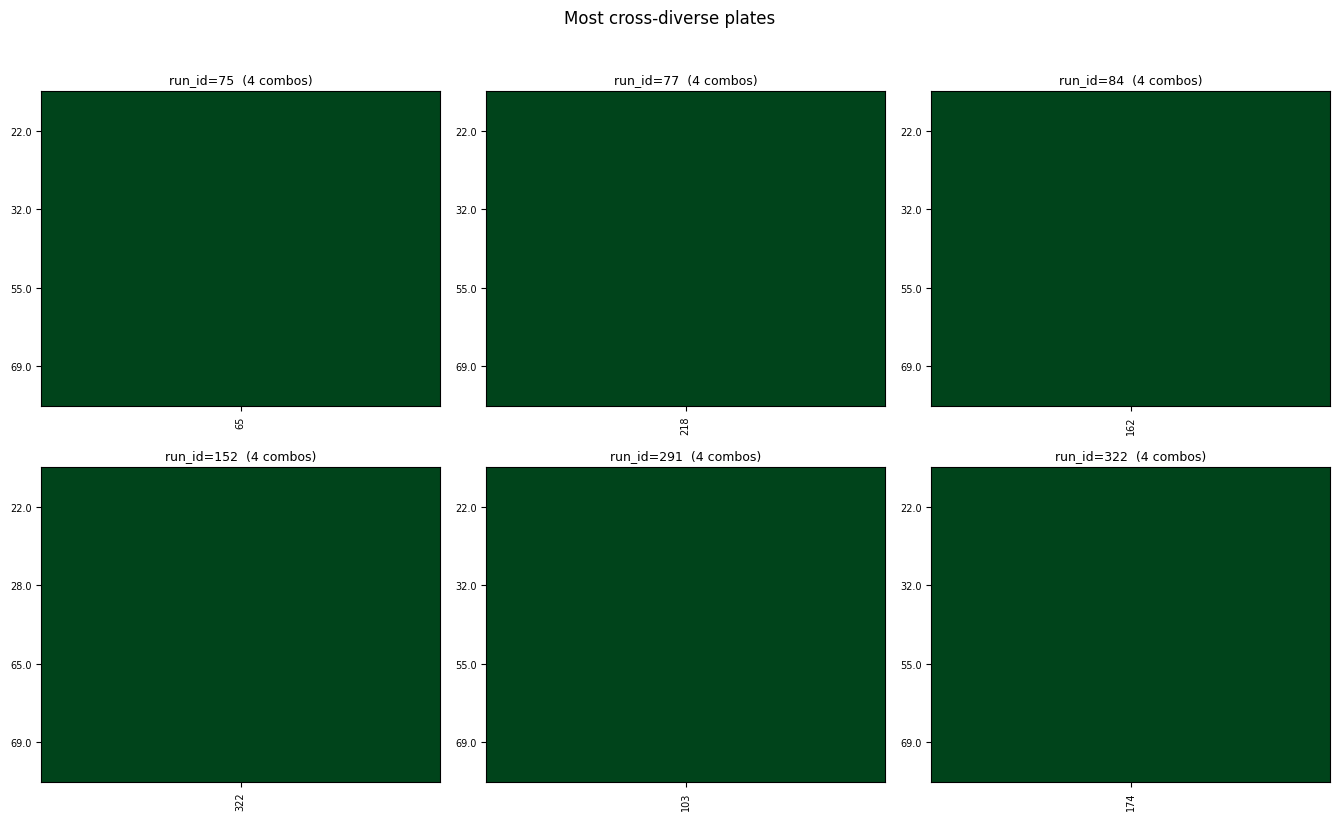

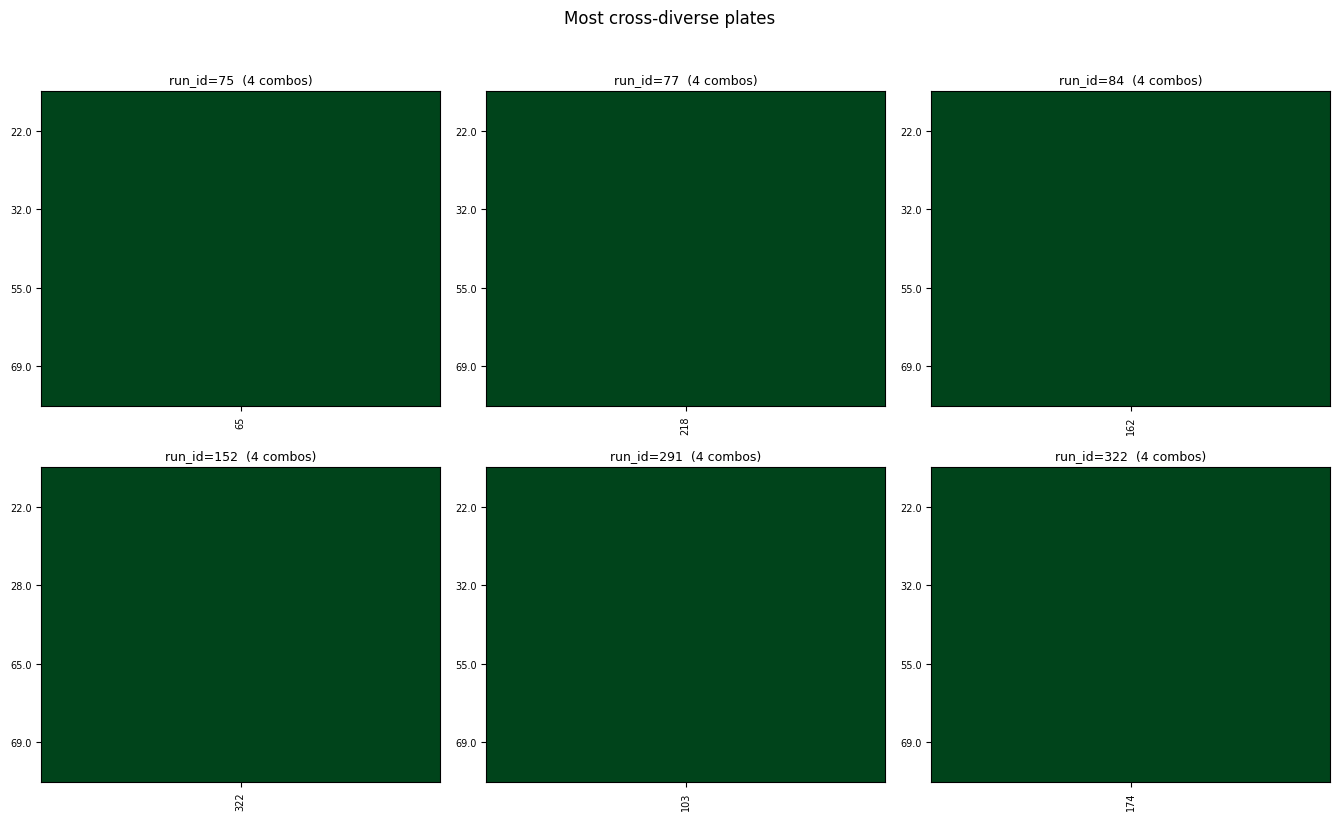

In [7]:
def plot_plate(run_id, ax=None):
    """Show exactly which mab x virus pairs are present on one plate."""
    sub = combos[combos["run_id"] == run_id]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    if HAS_MAB_VIRUS_SPLIT:
        mat = pd.crosstab(sub["mab"], sub["virus"])
        ax.imshow(mat.values, aspect="auto", cmap="Greens", vmin=0, vmax=1)
        ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns, rotation=90, fontsize=7)
        ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index, fontsize=7)
    else:
        ax.axis("off")
        ax.text(0, 1, "\n".join(sorted(sub["mab_virus"])), fontsize=7, va="top")
    ax.set_title(f"run_id={run_id}  ({len(sub)} combos)", fontsize=9)
    return ax


def plot_top_plates(n=6):
    ids = plate_diversity.head(n).index.tolist()
    ncols = 3
    nrows = -(-len(ids) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), squeeze=False)
    for ax, run_id in zip(axes.flat, ids):
        plot_plate(run_id, ax=ax)
    for ax in axes.flat[len(ids):]:
        ax.set_visible(False)
    fig.suptitle("Most cross-diverse plates", y=1.02)
    fig.tight_layout()
    return fig


plot_top_plates(6)

## Ideas for mucking around
- `plot_plate(run_id)` on its own for a specific plate you already have in mind.
- Filter `plate_diversity` for a minimum bar, e.g. `plate_diversity[(plate_diversity.n_mab >= 3) & (plate_diversity.n_virus >= 3)]`, if `cross_score` alone surfaces plates that are technically square but tiny (e.g. 2x2).
- Add more files to `DATA_PATHS` at the top and re-run to widen the search across dataset versions -- `combos` already carries a `source_file` column for that.
- `coverage` (from the heatmap cell) is a full mab x virus matrix -- `coverage[coverage == 0]` shows untested combos if you're looking for gaps rather than existing plates.